In [1]:
from fastbook import *
print("OK")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


OK


In [2]:
!pip install -q ddgs
from ddgs import DDGS
print("OK")

OK


In [3]:
from fastai.vision.all import *
from PIL import Image


In [4]:
# import urllib.request
# urllib.request.urlopen('https://www.google.com', timeout=5)

In [4]:
!pip install -U duckduckgo_search

In [5]:
import sys
!{sys.executable} -m pip install bing_image_downloader

In [6]:
from ddgs import DDGS

def search_images_ddg(term, max_images=100):
    with DDGS() as ddgs:
        results = list(ddgs.images(term, max_results=max_images))
    return [r['image'] for r in results]
    
from ddgs import DDGS

with DDGS() as ddgs:
    results = list(ddgs.images('grizzly bear', max_results=100))
urls = [r['image'] for r in results]
len(urls)

35

In [7]:
ims = search_images_ddg('grizzly bear')
len(ims)

74

In [8]:
import sys
print(sys.executable)

C:\Users\Prime\anaconda3\envs\fastai_env\python.exe


In [9]:
from pathlib import Path
import time

Path('images').mkdir(exist_ok=True)

for i, url in enumerate(ims[:20]):  # try first 20 URLs
    try:
        download_url(url, f'images/grizzly_{i}.jpg', show_progress=False, timeout=5)
        print(f"✓ downloaded {i}")
    except Exception as e:
        print(f"✗ skipped {i}: {e}")

✓ downloaded 0
✓ downloaded 1
✓ downloaded 2
✓ downloaded 3
✓ downloaded 4
✓ downloaded 5
✓ downloaded 6
✓ downloaded 7
✗ skipped 8: HTTP Error 403: Forbidden
====Error Body====
<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><meta http-equiv="content-security-policy" content="default-src &#39;none&#39;; script-src &#39;nonce-XOWQqSDYMq9Tw3rWpQ2GH9&#39; &#39;unsafe-eval&#39; https://challenges.cloudflare.com; script-src-attr &#39;none&#39;; style-src &#39;unsafe-inline&#39;; img-src &#39;self&#39; https://challenges.cloudflare.com; connect-src &#39;self&#39; https://challenges.cloudflare.com; frame-src &#39;self&#39; https://challenges.cloudflare.com blob:; child-src &#39;self&#39; https://challenges.cloudflare.com blob:; worker-src 

In [10]:
print(ims[0])  # see which URL is failing
dest = 'images/grizzly.jpg'
download_url(ims[3], dest, show_progress=False)  # try a different one

https://cdn.britannica.com/19/186719-050-887A6F2C/Grizzly-bear-Rocky-Mountains-Wyoming.jpg


Path('images/grizzly.jpg')

In [11]:
dest= 'images/grizzly.jpg'
download_url(ims[0],dest,show_progress=False)

Path('images/grizzly.jpg')

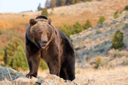

In [12]:
im = Image.open(dest)
im.to_thumb(128,128)

In [13]:
bear_types = 'grizzly','blackbear','teddybear'
path = Path('bears')

In [14]:
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest = (path/o)
        dest.mkdir(exist_ok = True)
        results =search_images_ddg(f'{o}bear')
        download_images(dest,urls=results)

In [15]:
fns = get_image_files(path)
fns

(#61) [Path('bears/black/0b04d867-de19-4703-9cbd-78ac1ab4d323.jpg'),Path('bears/black/117c01ff-3bab-4f49-bf20-0f3557220cc7.jpg'),Path('bears/black/14b9ac57-121d-4d0e-b139-19dd97d48e1e.jpg'),Path('bears/black/1c79e52a-5278-4106-8ac6-33fdb733db32.jpg'),Path('bears/black/23872dcd-03b4-424c-8a10-b48ee7d250b9.jpg'),Path('bears/black/24298c2a-d2e7-4fe1-b557-a18e89113907.jpg'),Path('bears/black/2b2a6e18-669f-40a2-b633-b0b123ed18b9.jpg'),Path('bears/black/2e07bcd7-7b1b-427b-95c2-352113788f79.jpg'),Path('bears/black/2e301d91-6dcc-4759-bb07-9a3f1a883fae.jpg'),Path('bears/black/3647d2f1-6314-4ad0-a65e-3b90c496c9a4.jpg')...]

In [16]:
failed = verify_images(fns)
failed

(#0) []

In [17]:
failed.map(Path.unlink)

(#0) []

In [18]:
bears = DataBlock(
    blocks = (ImageBlock,CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2,seed = 42),
    get_y = parent_label,
    item_tfms = Resize(128)
)

In [19]:
dls = bears.dataloaders(path)

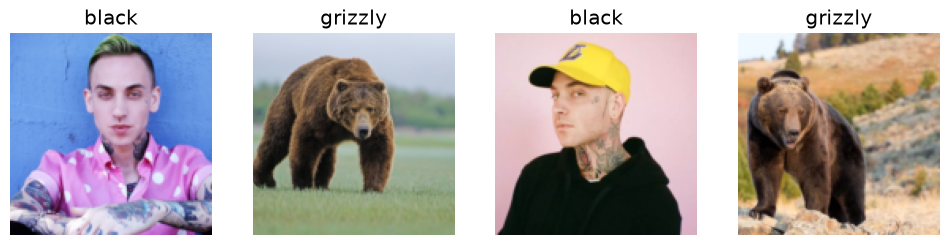

In [20]:
dls.valid.show_batch(max_n = 4,nrows = 1)

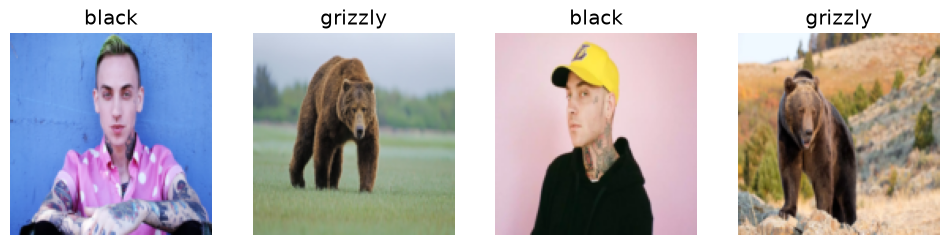

In [21]:
bears = bears.new(item_tfms = Resize(128,ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n = 4,nrows = 1)

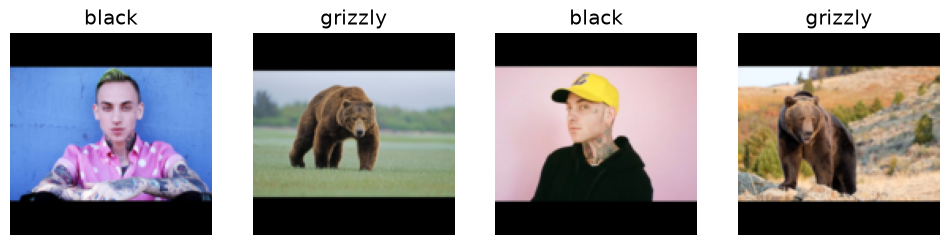

In [22]:
bears = bears.new(item_tfms = Resize(128,ResizeMethod.Pad,pad_mode = 'zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n = 4,nrows = 1)

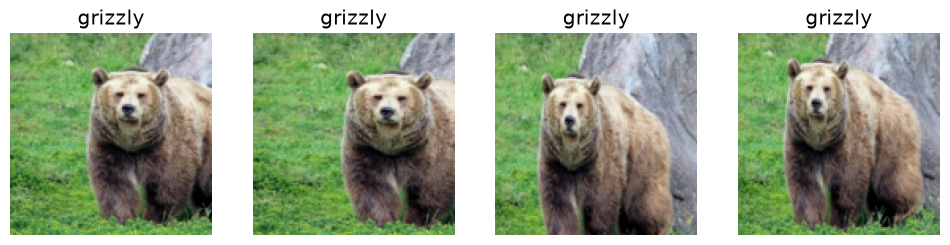

In [23]:
bears = bears.new(item_tfms = RandomResizedCrop(128,min_scale = 0.3))
dls = bears.dataloaders(path,bs=16)
dls.train.show_batch(max_n = 4,nrows = 1,unique = True)

In [24]:
from fastai.vision.all import get_image_files
fns = get_image_files(path)
len(fns)

61

In [25]:
from fastai.vision.all import verify_images
failed = verify_images(fns)
print(len(failed), "corrupted images")
failed.map(Path.unlink)  # deletes the bad ones

fns = get_image_files(path)
print(len(fns), "valid images remain")

0 corrupted images
61 valid images remain


In [26]:
print(len(get_image_files(path)))

61


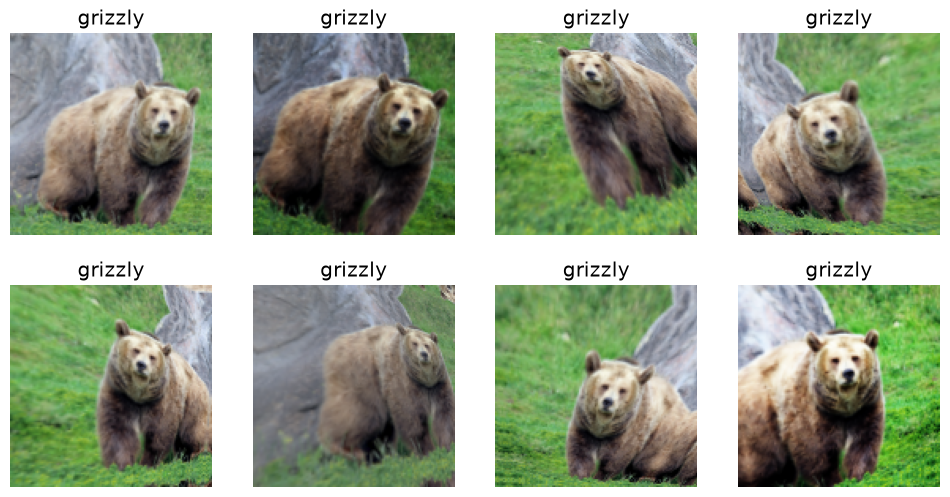

In [27]:
bears = bears.new(item_tfms = Resize(128),batch_tfms = aug_transforms(mult=2))
dls = bears.dataloaders(path,bs=16)
dls.train.show_batch(max_n = 8,nrows = 2,unique = True)

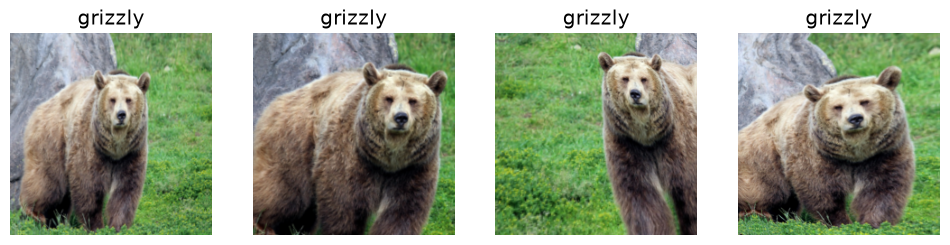

In [28]:
bears = bears.new(item_tfms = RandomResizedCrop(224,min_scale = 0.5),batch_tfms = aug_transforms())
dls = bears.dataloaders(path,bs=16)
dls.train.show_batch(max_n = 4,nrows = 1,unique = True)

In [29]:
learn = vision_learner(dls,resnet18 , metrics = error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,1.447198,0.174302,0.083333,00:16


epoch,train_loss,valid_loss,error_rate,time
0,0.406858,0.088892,0.000000,00:20
1,0.341324,0.017335,0.000000,00:20
2,0.253236,0.006490,0.000000,00:20
3,0.218643,0.005003,0.000000,00:20


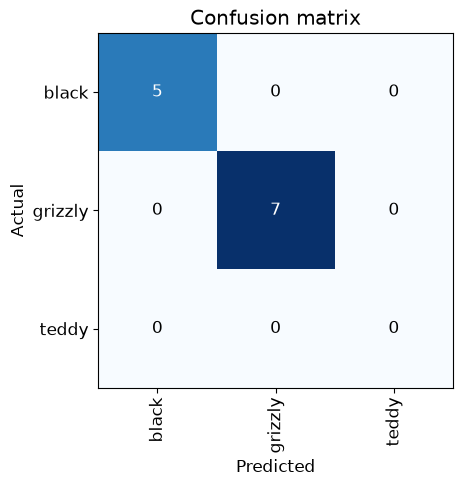

In [30]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

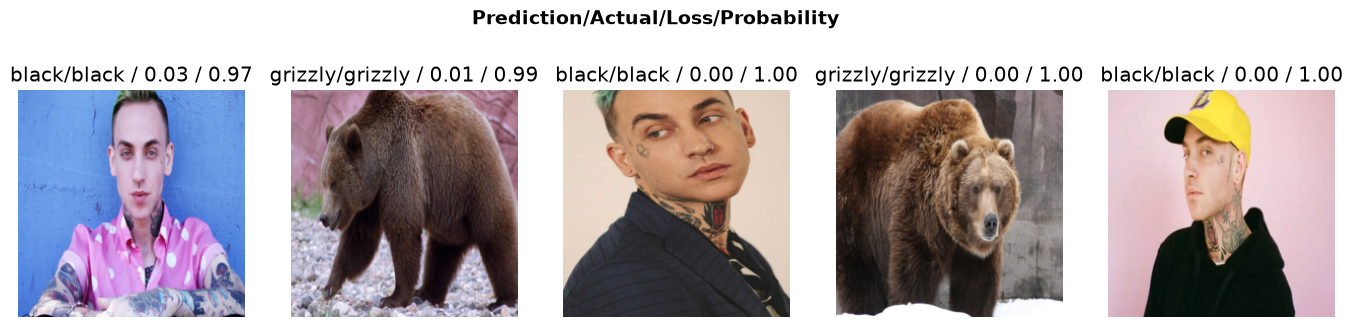

In [31]:
interp.plot_top_losses(5,nrows = 1,figsize = (17,4))

In [32]:
from fastai.vision.widgets import ImageClassifierCleaner
cleaner = ImageClassifierCleaner(learn)
cleaner

In [34]:
# for idx in cleaner.delete():cleaner.fns[idx].unlink()
# for idx,cat in cleaner.change():
#     shutil.move(str(cleaner.fns[idx]),path/cat)
# for idx in cleaner.delete():
#     cleaner.fns[idx].unlink()

# for idx,cat in cleaner.change():
#     shutil.move(str(cleaner.fns[idx]), path/cat)

In [35]:
learn.export()

In [36]:
path = Path()
path.ls(file_exts='.pkl')

(#1) [Path('export.pkl')]

In [37]:
learn_inf = load_learner(path/'export.pkl')

In [38]:
learn_inf.predict('images/grizzly.jpg')

('grizzly', tensor(1), tensor([7.8387e-05, 9.9816e-01, 1.7571e-03]))

In [39]:
learn_inf.dls.vocab

['black', 'grizzly', 'teddy']

In [40]:
#hide_output
btn_upload = widgets.FileUpload()
btn_upload


FileUpload(value={}, description='Upload')

In [41]:
#hide
# For the book, we can't actually click an upload button, so we fake it
btn_upload = SimpleNamespace(data = ['images/grizzly.jpg'])

In [42]:
img = PILImage.create(btn_upload.data[-1])

In [43]:
#hide_output
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl: display(img.to_thumb(128,128))
out_pl

Output()

In [44]:
pred,pred_idx,probs = learn_inf.predict(img)

In [45]:
#hide_output
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction: grizzly; Probability: 0.9982')

In [46]:
#hide_output
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [47]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [48]:
#hide
#Putting back btn_upload to a widget for next cell
btn_upload = widgets.FileUpload()

In [51]:
!pip install ipywidgets

In [55]:
#hide_output
import ipywidgets as widgets
from IPython.display import display
VBox = widgets.VBox
VBox([widgets.Label('Select your bear!'), 
      btn_upload, btn_run, out_pl, lbl_pred])

In [56]:
!pip install voila
!jupyter serverextension enable --sys-prefix voila

   ---------------------------------------- 0.0/4.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.5 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.5 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.5 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.5 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.5 MB 439.8 kB/s eta 0:00:10
   ---- ----------------------------------- 0.5/4.5 MB 439.8 kB/s eta 0:00:10
   ---- ----------------------------------- 0.5/4.5 MB 439.8 kB/s eta 0:00:10
   ------ --------------------------------- 0.8/4.5 MB 394.1 kB/s eta 0:00:10
   ------ --------------------------------- 0.8/4.5 MB 394.1 kB/s eta 0:00:10
   ------ --------------------------------- 0.8/4.5 MB 394.1 kB/s eta 0:00:10
   ------ --------------------------------- 0.8/4

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: builder console dejavu events execute kernel kernelspec
lab labextension labhub migrate nbconvert notebook qtconsole run script server
troubleshoot trust

Jupyter command `jupyter-serverextension` not found.
